## Imports

In [1]:
import re
from collections import Counter

import os

sys.path.append(os.path.abspath("../numpy"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from data import Data
from layers import DenseLayer
from activation import ReLUActivation, SoftmaxActivation
from neuralnet import NeuralNetwork
from losses import CategoricalCrossEntropy
from metrics import accuracy

## Ler os datasets

In [2]:
train_df = pd.read_csv("../dataset_master_final.csv", sep=";")
test_df = pd.read_csv("../subm2.csv", sep=";")


print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

display(train_df.head())
display(test_df.head())

Train shape: (50095, 3)
Test shape: (150, 2)


,Original_ID,Text,Label
0,WIKI-6574,Dipole distance (measured in Angstroms) and st...,OpenAI
1,WIKI-3987,It also seeks to analyse and describe the glob...,Human
2,WIKI-2364,The global ICAT technology has striking advant...,OpenAI
3,WIKI-5137,There are algorithms that can solve any proble...,Google
4,WIKI-9591,"CDE initiatives, for example, try to allow cli...",Human


,ID,Text
0,D2-101,Microbial mats of coexisting bacteria and arch...
1,D2-102,The origin of life on Earth remains a complex ...
2,D2-103,Estimates of the time at which life arose on E...
3,D2-104,Life on Earth emerged roughly 3.8-4 billion ye...
4,D2-105,Black holes predominantly form from the catast...


## Limpeza de texto

In [3]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def add_bigrams(text):
    words = text.split()
    bigrams = [words[i] + "_" + words[i+1] for i in range(len(words)-1)]
    return " ".join(words + bigrams)


cleanText=False ####################################### mudar 

if cleanText:
    train_df["clean_text"] = train_df["Text"].apply(clean_text)
    test_df["clean_text"] = test_df["Text"].apply(clean_text)
    print("com texto limpo")
else:
    train_df["clean_text"] = train_df["Text"]
    test_df["clean_text"] = test_df["Text"]
    print("sem texto limpo")

display(train_df[["Text", "clean_text", "Label"]].head())

sem texto limpo


,Text,clean_text,Label
0,Dipole distance (measured in Angstroms) and st...,Dipole distance (measured in Angstroms) and st...,OpenAI
1,It also seeks to analyse and describe the glob...,It also seeks to analyse and describe the glob...,Human
2,The global ICAT technology has striking advant...,The global ICAT technology has striking advant...,OpenAI
3,There are algorithms that can solve any proble...,There are algorithms that can solve any proble...,Google
4,"CDE initiatives, for example, try to allow cli...","CDE initiatives, for example, try to allow cli...",Human


## Ver classes

In [4]:
print("Classes:")
print(train_df["Label"].value_counts())

Classes:
Label
Human        10948
Google       10948
OpenAI       10606
Meta         10493
Anthropic     7100
Name: count, dtype: int64


## Construir vocabulário

Bag of Words

In [5]:
def build_vocab(texts, max_features=20000, min_freq=2):
    counter = Counter()
    
    for text in texts:
        counter.update(text.split())
    
    vocab_items = [
        word for word, freq in counter.items()
        if freq >= min_freq
    ]
    
    vocab_items = sorted(
        vocab_items,
        key=lambda word: counter[word],
        reverse=True
    )[:max_features]
    
    vocab = {word: idx for idx, word in enumerate(vocab_items)}
    return vocab



## Transformar texto em Bag of Words

In [6]:
def text_to_bow(texts, vocab):
    X = np.zeros((len(texts), len(vocab)), dtype=np.float32)
    
    for i, text in enumerate(texts):
        for word in text.split():
            if word in vocab:
                X[i, vocab[word]] += 1.0
                
    return X


## Transformar texto em TFIDF

In [7]:
def compute_idf(texts, vocab):
    n_docs = len(texts)
    df = np.zeros(len(vocab), dtype=np.float32)

    for text in texts:
        seen_words = set()
        for word in text.split():
            if word in vocab and word not in seen_words:
                df[vocab[word]] += 1
                seen_words.add(word)

    idf = np.log((n_docs + 1) / (df + 1)) + 1
    return idf

def text_to_tfidf(texts, vocab, idf):
    X = np.zeros((len(texts), len(vocab)), dtype=np.float32)

    for i, text in enumerate(texts):
        words = text.split()
        if len(words) == 0:
            continue

        for word in words:
            if word in vocab:
                X[i, vocab[word]] += 1.0

        X[i] = X[i] / len(words)
        X[i] = X[i] * idf

        norm = np.linalg.norm(X[i])
        if norm > 0:
            X[i] = X[i] / norm


    return X


## Codificar labels

In [8]:
def fit_label_encoder(labels):
    classes = sorted(labels.unique())
    label_to_idx = {label: i for i, label in enumerate(classes)}
    idx_to_label = {i: label for label, i in label_to_idx.items()}
    return label_to_idx, idx_to_label

def encode_labels(labels, label_to_idx):
    return np.array([label_to_idx[label] for label in labels], dtype=np.int32)

def one_hot_encode(y, num_classes):
    y_onehot = np.zeros((len(y), num_classes), dtype=np.float32)
    y_onehot[np.arange(len(y)), y] = 1.0
    return y_onehot


## Split treino / validação

In [9]:
def train_val_split(X, y, val_size=0.2, seed=42):
    np.random.seed(seed)
    indices = np.arange(len(X))
    np.random.shuffle(indices)
    
    split_idx = int(len(X) * (1 - val_size))
    train_idx = indices[:split_idx]
    val_idx = indices[split_idx:]
    
    return X[train_idx], X[val_idx], y[train_idx], y[val_idx]

texts = train_df["clean_text"].to_numpy()
labels = train_df["Label"].to_numpy()

X_train_text, X_val_text, y_train_text, y_val_text = train_val_split(texts, labels, val_size=0.2, seed=42)

print("X_train:", X_train_text.shape)
print("X_val:", X_val_text.shape)
print("y_train:", y_train_text.shape)
print("y_val:", y_val_text.shape)

X_train: (40076,)
X_val: (10019,)
y_train: (40076,)
y_val: (10019,)


In [10]:
def fit_vectorizer(texts_train, use_tfidf=True, use_bigrams=False, max_features=15000, min_freq=2):
    if use_bigrams:
        texts_train = np.array([add_bigrams(t) for t in texts_train])

    vocab = build_vocab(texts_train, max_features=max_features, min_freq=min_freq)

    vectorizer = {
        "use_tfidf": use_tfidf,
        "use_bigrams": use_bigrams,
        "vocab": vocab,
        "idf": None
    }

    if use_tfidf:
        vectorizer["idf"] = compute_idf(texts_train, vocab)

    return vectorizer

In [11]:
def transform_texts(texts, vectorizer):
    if vectorizer["use_bigrams"]:
        texts = np.array([add_bigrams(t) for t in texts])

    vocab = vectorizer["vocab"]

    if vectorizer["use_tfidf"]:
        idf = vectorizer["idf"]
        return text_to_tfidf(texts, vocab, idf)
    else:
        return text_to_bow(texts, vocab)

In [12]:
def run_experiment(
    model_name,
    texts_train,
    texts_val,
    y_train,
    y_val,
    use_tfidf=True,
    use_bigrams=False,
    max_features=15000,
    min_freq=2,
    epochs=50,
    batch_size=32,
    learning_rate=None,
    momentum=0.9
):
    vectorizer = fit_vectorizer(
        texts_train,
        use_tfidf=use_tfidf,
        use_bigrams=use_bigrams,
        max_features=max_features,
        min_freq=min_freq
    )

    X_train = transform_texts(texts_train, vectorizer)
    X_val = transform_texts(texts_val, vectorizer)

    train_data = Data(X_train, y_train)
    val_data = Data(X_val, y_val)

    if model_name == "logreg":
        if learning_rate is None:
            learning_rate = 0.05

        model = NeuralNetwork(
            epochs=epochs,
            batch_size=batch_size,
            learning_rate=learning_rate,
            momentum=momentum,
            verbose=True,
            loss=CategoricalCrossEntropy,
            metric=accuracy
        )
        model.add(DenseLayer(y_train.shape[1], input_shape=(X_train.shape[1],), l2_lambda=1e-4))
        model.add(SoftmaxActivation())

    elif model_name == "dnn":
        if learning_rate is None:
            learning_rate = 0.1

        model = NeuralNetwork(
            epochs=epochs,
            batch_size=batch_size,
            learning_rate=learning_rate,
            momentum=momentum,
            verbose=True,
            loss=CategoricalCrossEntropy,
            metric=accuracy
        )
        model.add(DenseLayer(128, input_shape=(X_train.shape[1],), l2_lambda=1e-4))
        model.add(ReLUActivation())
        model.add(DenseLayer(64, l2_lambda=1e-4))
        model.add(ReLUActivation())
        model.add(DenseLayer(y_train.shape[1], l2_lambda=1e-4))
        model.add(SoftmaxActivation())

    else:
        raise ValueError("model_name must be 'logreg' or 'dnn'")

    model.fit(train_data, val_dataset=val_data, early_stopping=True, patience=5)

    preds = model.predict(val_data)
    acc = accuracy(y_val, preds)

    return {
        "model": model,
        "vectorizer": vectorizer,
        "val_accuracy": acc,
        "history": model.history
    }

In [13]:
texts = train_df["clean_text"].to_numpy()
labels = train_df["Label"].to_numpy()

X_train_text, X_val_text, y_train_text, y_val_text = train_val_split(
    texts, labels, val_size=0.2, seed=42
)

label_to_idx, idx_to_label = fit_label_encoder(train_df["Label"])

y_train_idx = encode_labels(y_train_text, label_to_idx)
y_val_idx = encode_labels(y_val_text, label_to_idx)

num_classes = len(label_to_idx)
y_train = one_hot_encode(y_train_idx, num_classes)
y_val = one_hot_encode(y_val_idx, num_classes)

## Modelos


In [ ]:
results = {}

In [14]:
results = {}

results["logreg_bow"] = run_experiment(
    model_name="logreg",
    texts_train=X_train_text,
    texts_val=X_val_text,
    y_train=y_train,
    y_val=y_val,
    use_tfidf=False,
    use_bigrams=False
)

results["logreg_tfidf"] = run_experiment(
    model_name="logreg",
    texts_train=X_train_text,
    texts_val=X_val_text,
    y_train=y_train,
    y_val=y_val,
    use_tfidf=True,
    use_bigrams=False
)

results["logreg_tfidf_bigram"] = run_experiment(
    model_name="logreg",
    texts_train=X_train_text,
    texts_val=X_val_text,
    y_train=y_train,
    y_val=y_val,
    use_tfidf=True,
    use_bigrams=True
)


results["dnn_bow"] = run_experiment(
    model_name="dnn",
    texts_train=X_train_text,
    texts_val=X_val_text,
    y_train=y_train,
    y_val=y_val,
    use_tfidf=False,
    use_bigrams=False
)

results["dnn_tfidf"] = run_experiment(
    model_name="dnn",
    texts_train=X_train_text,
    texts_val=X_val_text,
    y_train=y_train,
    y_val=y_val,
    use_tfidf=True,
    use_bigrams=False
)



results["dnn_tfidf_bigram"] = run_experiment(
    model_name="dnn",
    texts_train=X_train_text,
    texts_val=X_val_text,
    y_train=y_train,
    y_val=y_val,
    use_tfidf=True,
    use_bigrams=True
)

Epoch 1/50 - loss: 0.5553 - acc: 0.8411 - val_loss: 0.3485 - val_acc: 0.9110
Epoch 2/50 - loss: 0.2835 - acc: 0.9281 - val_loss: 0.2643 - val_acc: 0.9259
Epoch 3/50 - loss: 0.2200 - acc: 0.9447 - val_loss: 0.2264 - val_acc: 0.9380
Epoch 4/50 - loss: 0.1853 - acc: 0.9550 - val_loss: 0.2052 - val_acc: 0.9424
Epoch 5/50 - loss: 0.1629 - acc: 0.9617 - val_loss: 0.1873 - val_acc: 0.9476
Epoch 6/50 - loss: 0.1460 - acc: 0.9672 - val_loss: 0.1828 - val_acc: 0.9465
Epoch 7/50 - loss: 0.1330 - acc: 0.9705 - val_loss: 0.1683 - val_acc: 0.9514
Epoch 8/50 - loss: 0.1230 - acc: 0.9735 - val_loss: 0.1618 - val_acc: 0.9519
Epoch 9/50 - loss: 0.1141 - acc: 0.9758 - val_loss: 0.1553 - val_acc: 0.9542
Epoch 10/50 - loss: 0.1072 - acc: 0.9779 - val_loss: 0.1506 - val_acc: 0.9548
Epoch 11/50 - loss: 0.1010 - acc: 0.9812 - val_loss: 0.1504 - val_acc: 0.9541
Epoch 12/50 - loss: 0.0956 - acc: 0.9817 - val_loss: 0.1446 - val_acc: 0.9555
Epoch 13/50 - loss: 0.0911 - acc: 0.9831 - val_loss: 0.1435 - val_acc: 0.

## Graficos

In [15]:
def plot_history(history, title="Model"):
    epochs = list(history.keys())

    train_loss = [history[e]["loss"] for e in epochs]
    val_loss = [history[e]["val_loss"] for e in epochs]
    train_acc = [history[e]["metric"] for e in epochs]
    val_acc = [history[e]["val_metric"] for e in epochs]

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_loss, label="Train Loss")
    plt.plot(epochs, val_loss, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} - Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_acc, label="Train Accuracy")
    plt.plot(epochs, val_acc, label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title} - Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

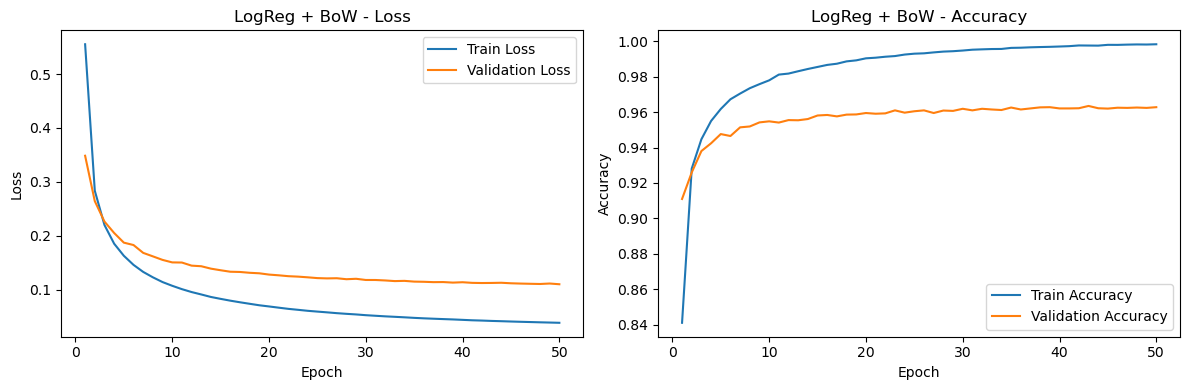

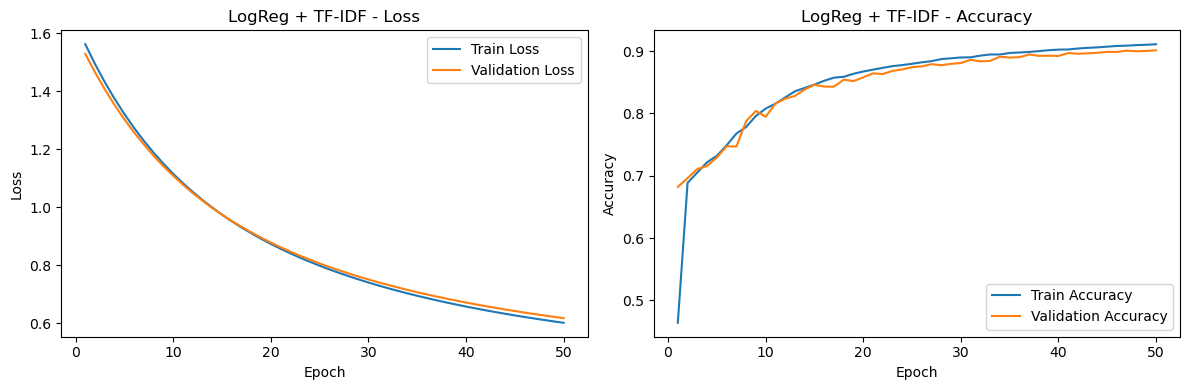

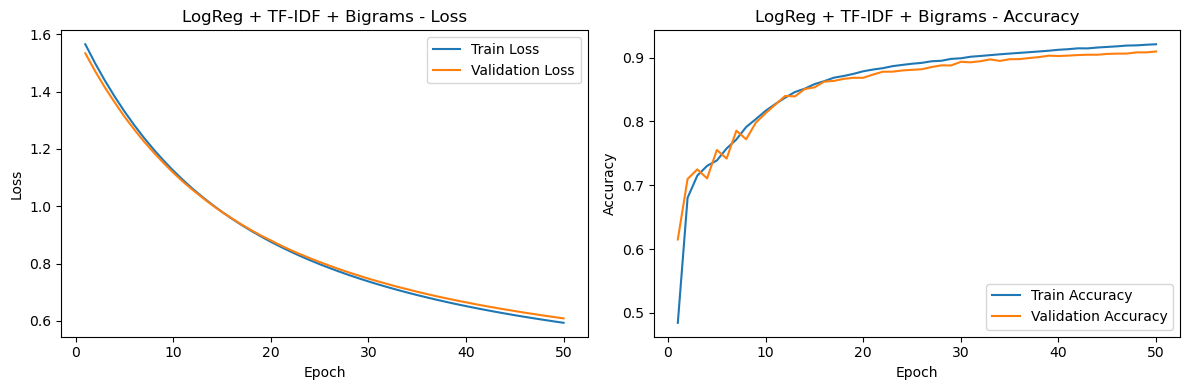

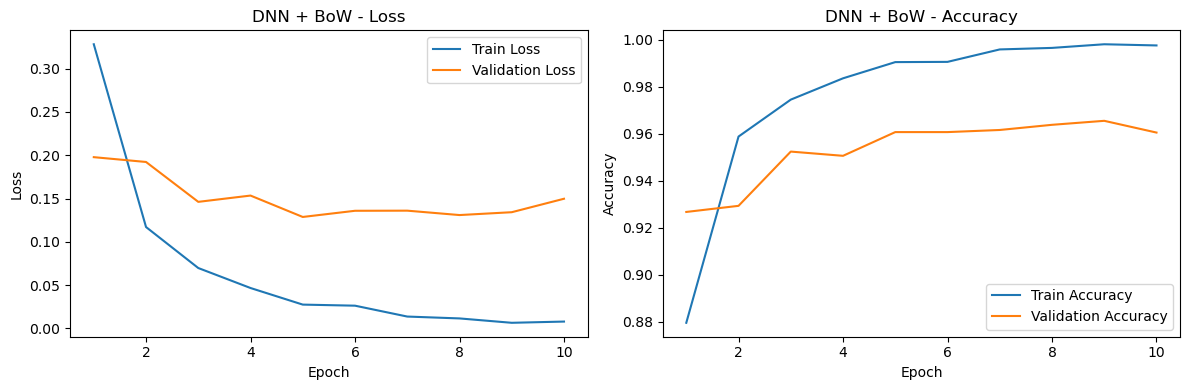

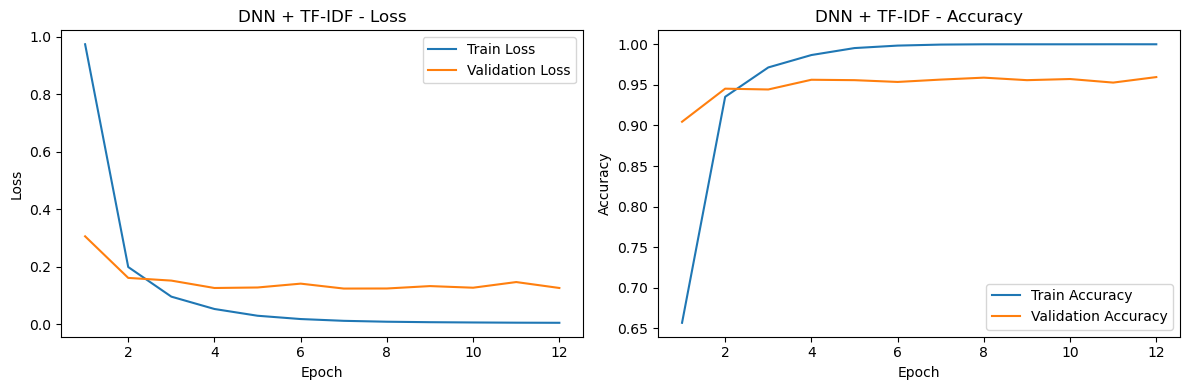

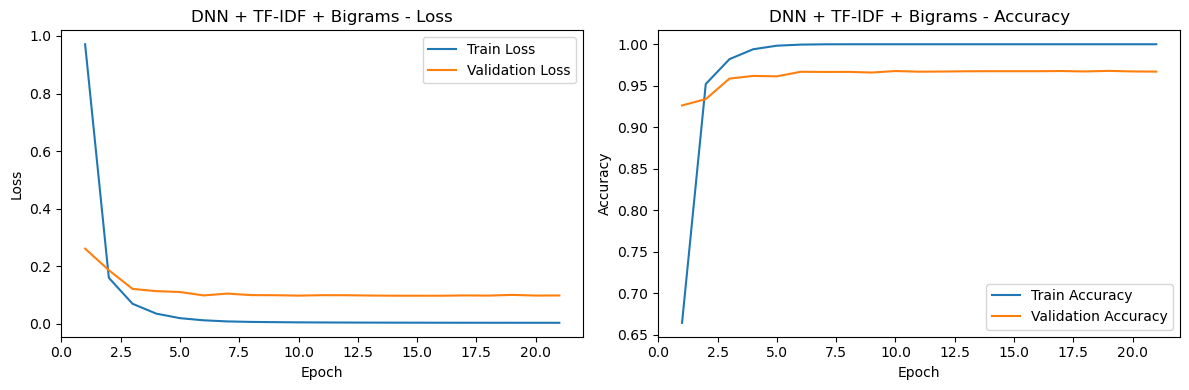

In [16]:
plot_history(results["logreg_bow"]["history"], title="LogReg + BoW")
plot_history(results["logreg_tfidf"]["history"], title="LogReg + TF-IDF")
plot_history(results["logreg_tfidf_bigram"]["history"], title="LogReg + TF-IDF + Bigrams")
plot_history(results["dnn_bow"]["history"], title="DNN + BoW")
plot_history(results["dnn_tfidf"]["history"], title="DNN + TF-IDF")
plot_history(results["dnn_tfidf_bigram"]["history"], title="DNN + TF-IDF + Bigrams")

## Escolher o melhor modelo

In [17]:
for name, result in results.items():
    print(name, "->", result["val_accuracy"])

best_model_name = max(results, key=lambda k: results[k]["val_accuracy"])
best_result = results[best_model_name]

best_model = best_result["model"]
best_vectorizer = best_result["vectorizer"]

print("Best model:", best_model_name)
print("Validation accuracy:", best_result["val_accuracy"])

logreg_bow -> 0.9627707356023555
logreg_tfidf -> 0.9014871743686995
logreg_tfidf_bigram -> 0.9096716239145624
dnn_bow -> 0.9606747180357321
dnn_tfidf -> 0.9564826829024853
dnn_tfidf_bigram -> 0.9675616328974947
Best model: dnn_tfidf_bigram
Validation accuracy: 0.9675616328974947


In [18]:
def confusion_matrix_numpy(y_true, y_pred, num_classes):
    cm = np.zeros((num_classes, num_classes), dtype=int)
    
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
        
    return cm

def plot_confusion_matrix(cm, class_names, title="Confusion Matrix"):
    plt.figure(figsize=(6, 5))
    plt.imshow(cm, cmap="Blues")
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j],
                     ha="center", va="center",
                     color="black")

    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

# TESTE COM SUMB1 COM LABELS

In [19]:
val_test_df = pd.read_csv("../subm1_labels_revealed.csv", sep=";")

display(val_test_df.head())

,ID,Text,Label
0,D2-1,A covalent bond is a chemical bond that involv...,Human
1,D2-2,A covalent bond forms when two atoms share one...,Anthropic
2,D2-3,A covalent bond is a type of chemical bond whe...,OpenAI
3,D2-4,A covalent bond is a chemical bond that involv...,Meta
4,D2-5,Driven by exciting developments in the field o...,Human


In [20]:
val_test_df["clean_text"] = val_test_df["Text"]
#val_test_df["clean_text"] = val_test_df["Text"].apply(clean_text)
texts_val_test = val_test_df["clean_text"].to_numpy()


In [21]:
test_results = {}
conf_matrices = {}

true_idx = np.array([label_to_idx[label] for label in val_test_df["Label"]])

for name, result in results.items():
    model = result["model"]
    vectorizer = result["vectorizer"]

    X_val_test = transform_texts(texts_val_test, vectorizer)
    val_test_data = Data(X_val_test, y=None)

    preds = model.predict(val_test_data)
    pred_idx = np.argmax(preds, axis=1)

    acc = np.mean(pred_idx == true_idx)

    cm = confusion_matrix_numpy(true_idx, pred_idx, num_classes)
    conf_matrices[name] = cm

    test_results[name] = acc
    print(f"{name}: {acc:.4f}")

logreg_bow: 0.6900
logreg_tfidf: 0.6400
logreg_tfidf_bigram: 0.6300
dnn_bow: 0.6800
dnn_tfidf: 0.6600
dnn_tfidf_bigram: 0.6600


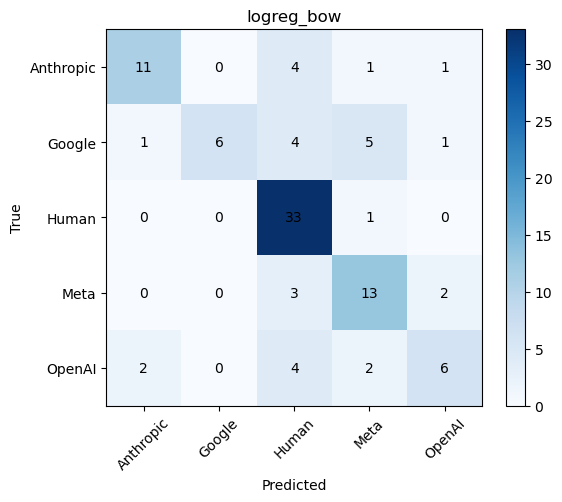

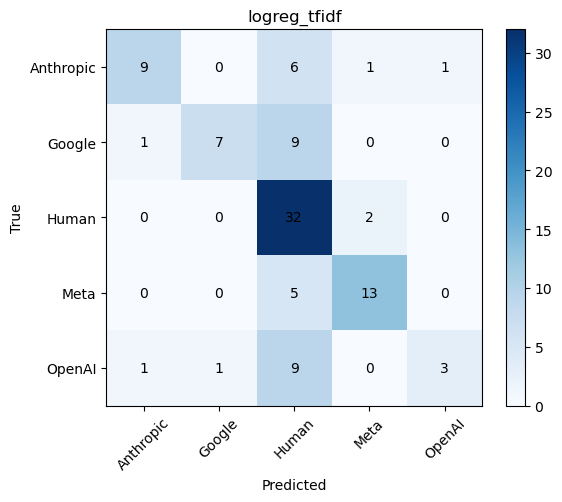

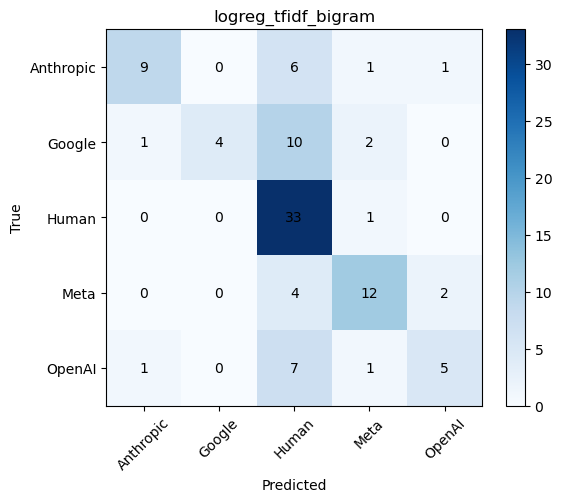

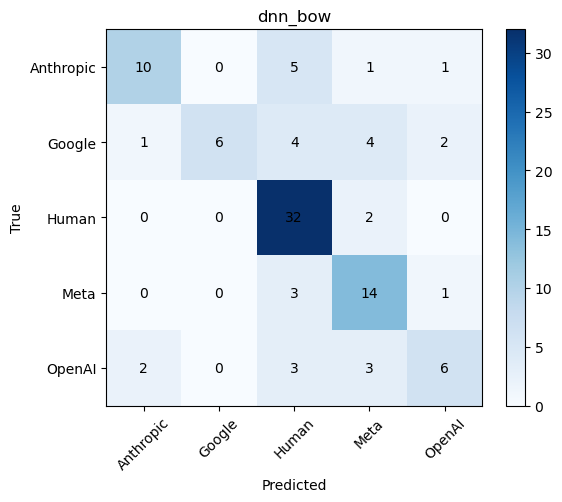

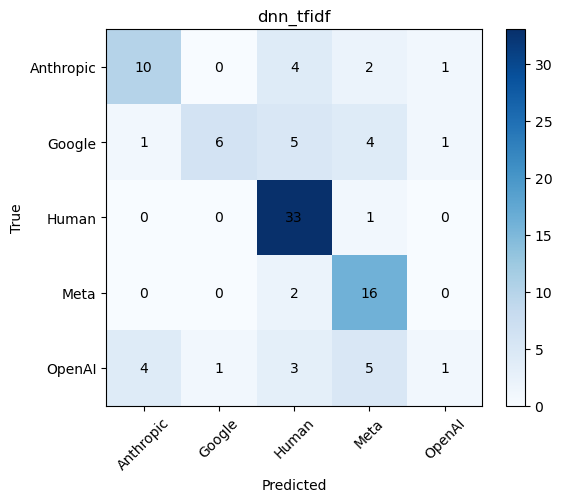

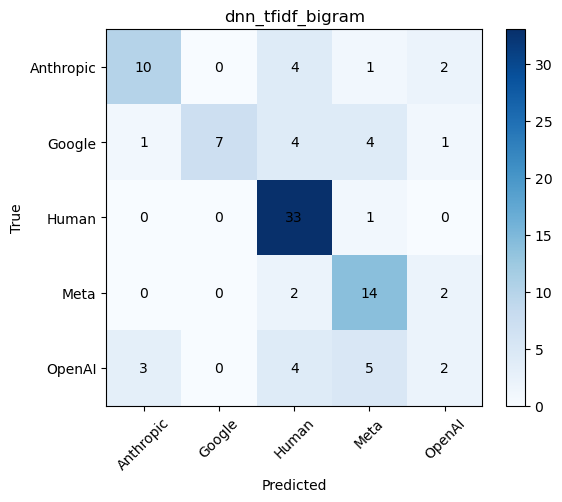

In [22]:
class_names = [k for k, v in sorted(label_to_idx.items(), key=lambda x: x[1])]

for name, cm in conf_matrices.items():
    plot_confusion_matrix(cm, class_names, title=name)

In [23]:
pred_labels = [idx_to_label[i] for i in pred_idx]
for i in range(10):
    print("Texto:", val_test_df["Text"].iloc[i][:80])
    print("Real:", val_test_df["Label"].iloc[i])
    print("Pred:", pred_labels[i])
    print("---")

Texto: A covalent bond is a chemical bond that involves the sharing of electrons to for
Real: Human
Pred: Human
---
Texto: A covalent bond forms when two atoms share one or more pairs of electrons, rathe
Real: Anthropic
Pred: Anthropic
---
Texto: A covalent bond is a type of chemical bond where two atoms share one or more pai
Real: OpenAI
Pred: Human
---
Texto: A covalent bond is a chemical bond that involves the sharing of electron pairs b
Real: Meta
Pred: Meta
---
Texto: Driven by exciting developments in the field of nanotechnology, which is one of 
Real: Human
Pred: Human
---
Texto: Ionic bonding results from the electrostatic attraction of oppositely charged io
Real: Human
Pred: Human
---
Texto: Plate tectonics is the scientific theory explaining how Earth's lithosphere—the 
Real: Anthropic
Pred: Anthropic
---
Texto: Plate tectonics is a fundamental scientific theory explaining the large-scale mo
Real: Google
Pred: Meta
---
Texto: Tectonic plates are relatively rigid and float acr

# TESTE COM SUMB2 COM LABELS

In [24]:
val_test2_df = pd.read_csv("../subm2_labels_revealed.csv", sep=";")

display(val_test2_df.head())

,ID,Text,Label
0,D2-101,Microbial mats of coexisting bacteria and arch...,Human
1,D2-102,The origin of life on Earth remains a complex ...,OpenAI
2,D2-103,Estimates of the time at which life arose on E...,Human
3,D2-104,Life on Earth emerged roughly 3.8-4 billion ye...,Anthropic
4,D2-105,Black holes predominantly form from the catast...,Google


In [25]:
val_test2_df["clean_text"] = val_test2_df["Text"]
#val_test2_df["clean_text"] = val_test2_df["Text"].apply(clean_text)
texts_val_test2 = val_test2_df["clean_text"].to_numpy()


In [26]:
test2_results = {}
conf2_matrices = {}

true_idx = np.array([label_to_idx[label] for label in val_test2_df["Label"]])

for name, result in results.items():
    model = result["model"]
    vectorizer = result["vectorizer"]

    X_val_test2 = transform_texts(texts_val_test2, vectorizer)

    val_test2_data = Data(X_val_test2, y=None)

    preds = model.predict(val_test2_data)
    pred_idx = np.argmax(preds, axis=1)

    acc = np.mean(pred_idx == true_idx)

    cm = confusion_matrix_numpy(true_idx, pred_idx, num_classes)

    conf2_matrices[name] = cm
    test2_results[name] = acc
    print(f"{name}: {acc:.4f}")

logreg_bow: 0.5900
logreg_tfidf: 0.5700
logreg_tfidf_bigram: 0.5900
dnn_bow: 0.6100
dnn_tfidf: 0.6200
dnn_tfidf_bigram: 0.6100


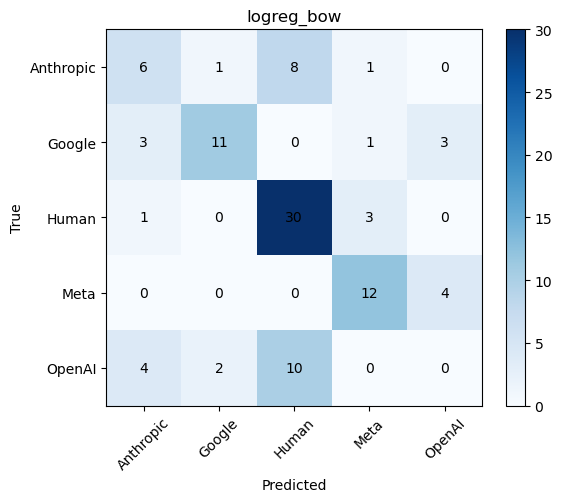

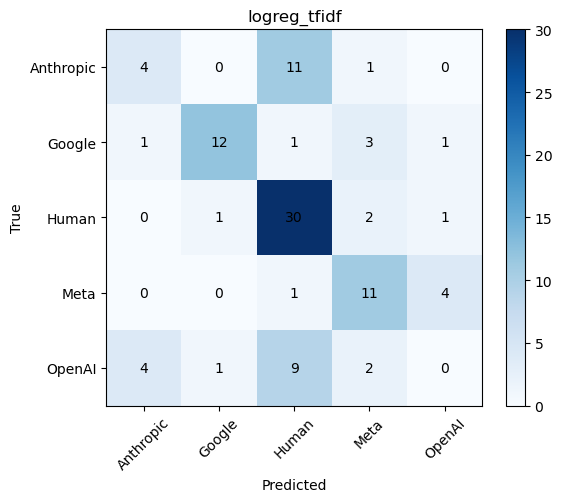

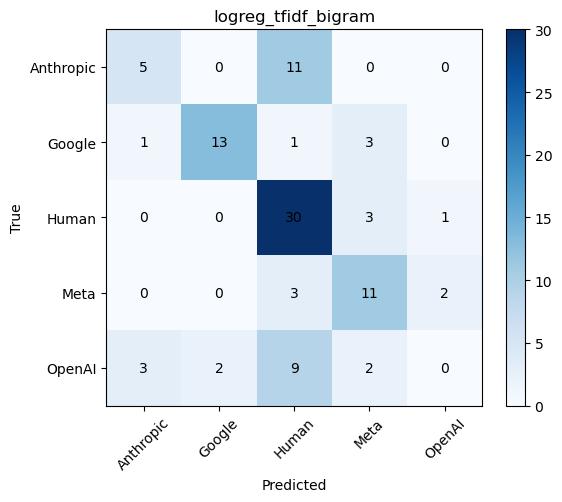

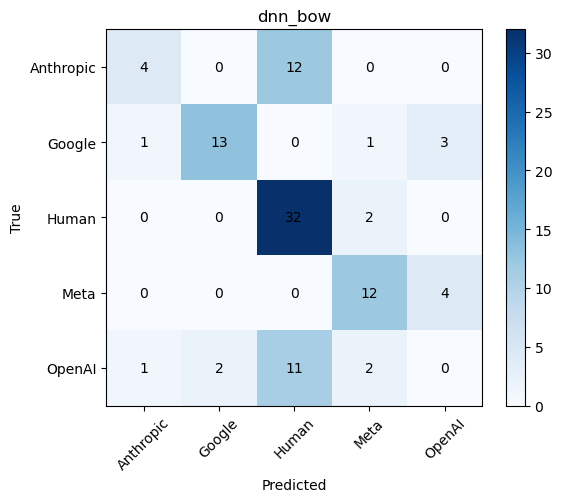

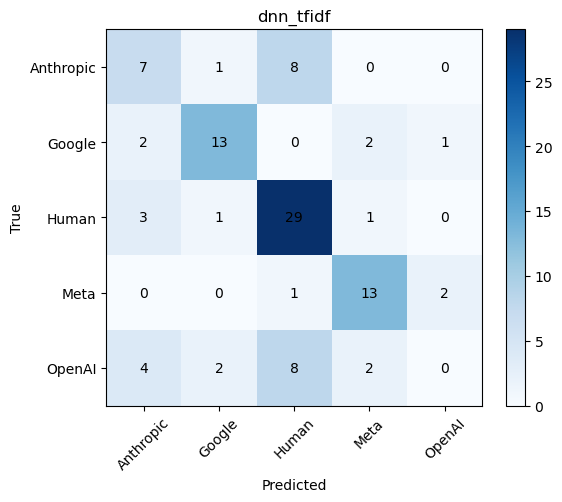

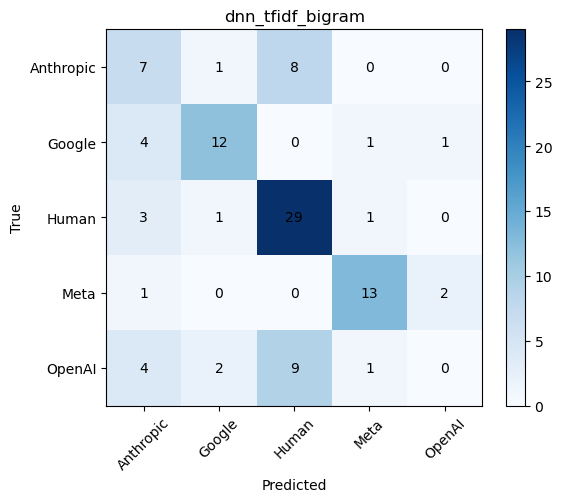

In [27]:
class_names = [k for k, v in sorted(label_to_idx.items(), key=lambda x: x[1])]

for name, cm in conf2_matrices.items():
    plot_confusion_matrix(cm, class_names, title=name)

In [28]:
pred_labels = [idx_to_label[i] for i in pred_idx]
for i in range(10):
    print("Texto:", val_test2_df["Text"].iloc[i][:80])
    print("Real:", val_test2_df["Label"].iloc[i])
    print("Pred:", pred_labels[i])
    print("---")

Texto: Microbial mats of coexisting bacteria and archaea were the dominant form of life
Real: Human
Pred: Human
---
Texto: The origin of life on Earth remains a complex and debated topic, but most scient
Real: OpenAI
Pred: Human
---
Texto: Estimates of the time at which life arose on Earth make use of two types of evid
Real: Human
Pred: Human
---
Texto: Life on Earth emerged roughly 3.8-4 billion years ago through a process still no
Real: Anthropic
Pred: Anthropic
---
Texto: Black holes predominantly form from the catastrophic death of incredibly massive
Real: Google
Pred: Anthropic
---
Texto: Black holes form primarily through the death of massive stars. When a star with 
Real: Anthropic
Pred: Anthropic
---
Texto: Black holes are formed when a massive star runs out of fuel and its core collaps
Real: Human
Pred: Meta
---
Texto: Black holes form when massive stars collapse under their own gravity at the end 
Real: OpenAI
Pred: Anthropic
---
Texto: Supermassive black holes are extraordin

# TESTE COM o Dataset de Teste

In [29]:
val_test3_df = pd.read_csv("../dataset_final_v3.csv", sep=";")

display(val_test3_df.head())

,ID,Text,Label
0,D1-0001,Microbial genetics explores how genes control ...,OpenAI
1,D1-0002,"White dwarfs are the dense, hot stellar cores ...",Meta
2,D1-0003,Diodes are two-terminal semiconductor devices ...,Anthropic
3,D1-0004,"Decoy State Quantum Key Distribution (QKD), be...",Human
4,D1-0005,Wireless power transfer is an emerging field i...,OpenAI


In [30]:
val_test3_df["clean_text"] = val_test3_df["Text"]
#val_test3_df["clean_text"] = val_test3_df["Text"].apply(clean_text)
texts_val_test3 = val_test3_df["clean_text"].to_numpy()


In [31]:
test3_results = {}
conf3_matrices = {}

true_idx = np.array([label_to_idx[label] for label in val_test3_df["Label"]])

for name, result in results.items():
    model = result["model"]
    vectorizer = result["vectorizer"]

    X_val_test3 = transform_texts(texts_val_test3, vectorizer)

    val_test3_data = Data(X_val_test3, y=None)

    preds = model.predict(val_test3_data)
    pred_idx = np.argmax(preds, axis=1)

    acc = np.mean(pred_idx == true_idx)

    cm = confusion_matrix_numpy(true_idx, pred_idx, num_classes)

    conf3_matrices[name] = cm
    test3_results[name] = acc
    print(f"{name}: {acc:.4f}")

logreg_bow: 0.2353
logreg_tfidf: 0.2120
logreg_tfidf_bigram: 0.2179
dnn_bow: 0.2273
dnn_tfidf: 0.2568
dnn_tfidf_bigram: 0.2522


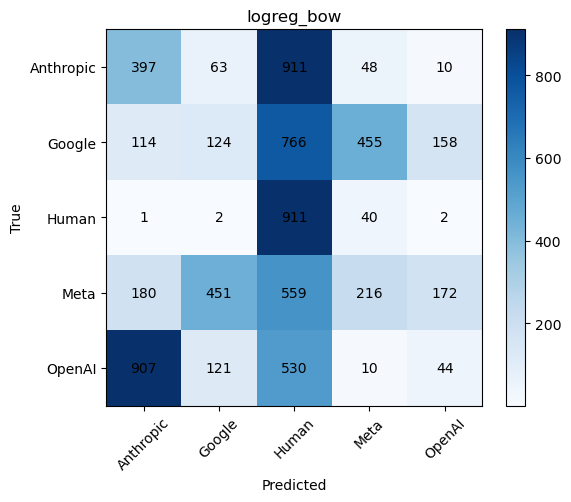

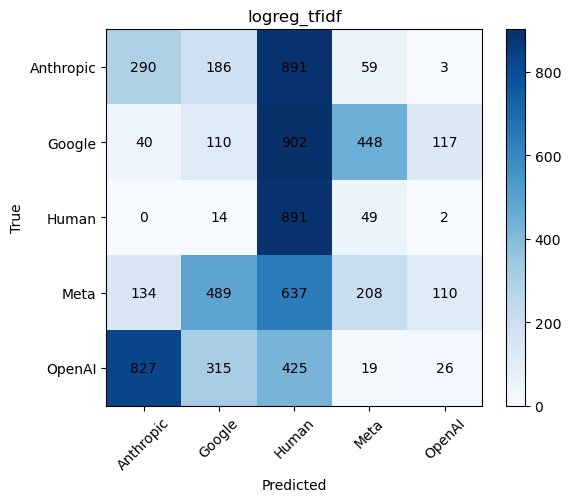

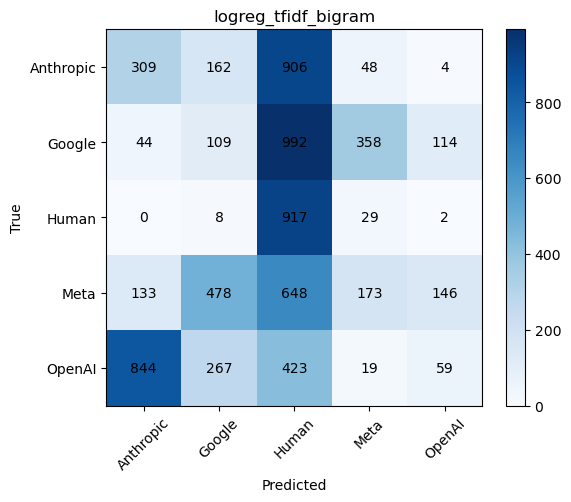

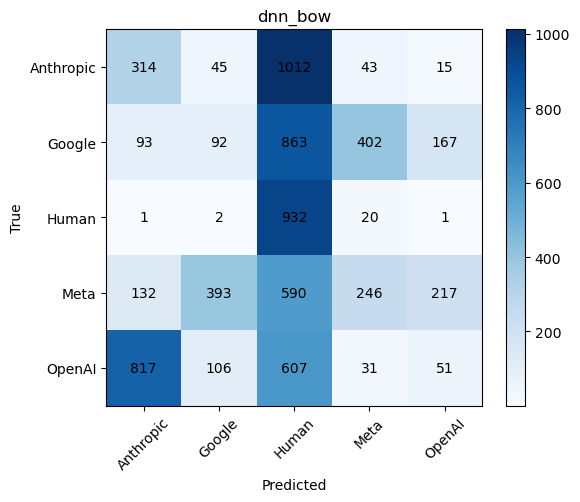

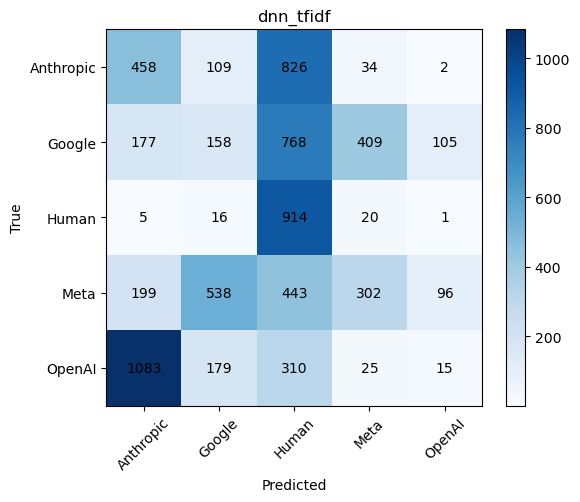

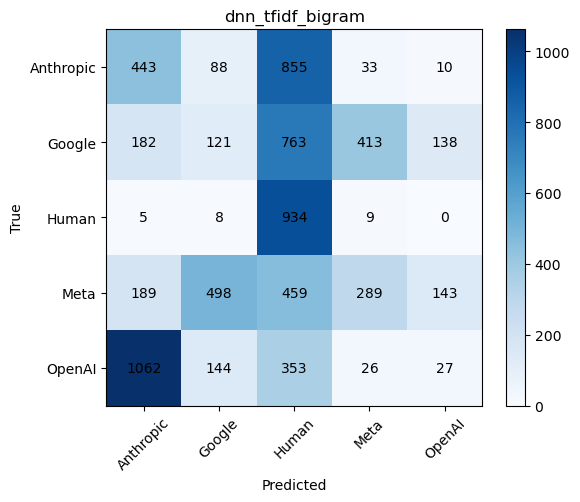

In [32]:
class_names = [k for k, v in sorted(label_to_idx.items(), key=lambda x: x[1])]

for name, cm in conf3_matrices.items():
    plot_confusion_matrix(cm, class_names, title=name)

In [33]:
pred_labels = [idx_to_label[i] for i in pred_idx]
for i in range(10):
    print("Texto:", val_test3_df["Text"].iloc[i][:80])
    print("Real:", val_test3_df["Label"].iloc[i])
    print("Pred:", pred_labels[i])
    print("---")

Texto: Microbial genetics explores how genes control cellular processes and how genetic
Real: OpenAI
Pred: Anthropic
---
Texto: White dwarfs are the dense, hot stellar cores left behind after low-to-medium ma
Real: Meta
Pred: Meta
---
Texto: Diodes are two-terminal semiconductor devices that allow current to flow predomi
Real: Anthropic
Pred: Human
---
Texto: Decoy State Quantum Key Distribution (QKD), being capable of beating PNS attack 
Real: Human
Pred: Human
---
Texto: Wireless power transfer is an emerging field in electrical engineering, enabling
Real: OpenAI
Pred: Anthropic
---
Texto: Calculus plays a pivotal role in physics, forming the mathematical language for 
Real: Meta
Pred: Google
---
Texto: The chain rule is a crucial technique in differential calculus used for finding 
Real: Google
Pred: Human
---
Texto: Kin selection is an evolutionary mechanism through which alleles that promote al
Real: Anthropic
Pred: Human
---
Texto: Phylogenetics is the scientific discipline conce

# Predict Submision

In [22]:
model_name = "logreg_bow"   # escolhe aqui
#model_name = max(results, key=lambda k: results[k]["val_accuracy"])

In [23]:
selected_result = results[model_name]

model = selected_result["model"]
vectorizer = selected_result["vectorizer"]

print("Using model:", model_name)

Using model: logreg_bow


In [24]:
X_test = transform_texts(test_df["clean_text"].to_numpy(), vectorizer)

In [25]:
test_data = Data(X_test, y=None)

In [26]:
pred_probs = model.predict(test_data)
pred_idx = np.argmax(pred_probs, axis=1)

In [27]:
pred_labels = [idx_to_label[i] for i in pred_idx]

In [28]:
submission = pd.DataFrame({
    "ID": test_df["ID"],
    "Label": pred_labels
})

submission.to_csv("subm2-g6-MEI-A.csv", sep=";", index=False)
display(submission.head())

,ID,Label
0,D2-101,Human
1,D2-102,Google
2,D2-103,Google
3,D2-104,OpenAI
4,D2-105,Anthropic
